In [1]:
!pip install duckdb openpyxl pandas matplotlib seaborn -q

In [4]:
!pip install duckdb openpyxl -q

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


In [5]:
import pandas as pd
import duckdb

df = pd.read_excel("Online Retail.xlsx")

print("Rows:", len(df))
print("Columns:", list(df.columns))

Rows: 541909
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [6]:
con = duckdb.connect()

con.register("retail_data", df)

print(con.execute("SELECT COUNT(*) FROM retail_data").fetchone()[0])

541909


In [7]:
result = con.execute("""
SELECT *
FROM retail_data
LIMIT 10
""").df()

result

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [8]:
check = con.execute("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT InvoiceNo) AS total_invoices,
    COUNT(DISTINCT CustomerID) AS unique_customers,
    SUM(CASE WHEN CustomerID IS NULL THEN 1 ELSE 0 END) AS missing_customer_id,
    SUM(CASE WHEN Quantity <= 0 THEN 1 ELSE 0 END) AS invalid_quantity,
    SUM(CASE WHEN UnitPrice <= 0 THEN 1 ELSE 0 END) AS invalid_price,
    SUM(CASE WHEN CAST(InvoiceNo AS VARCHAR) LIKE 'C%' THEN 1 ELSE 0 END) AS cancelled_rows
FROM retail_data
""").df()

check

,total_rows,total_invoices,unique_customers,missing_customer_id,invalid_quantity,invalid_price,cancelled_rows
0,541909,25900,4372,135080.0,10624.0,2517.0,9288.0


In [9]:
con.execute("""
CREATE OR REPLACE TABLE customers AS
SELECT DISTINCT
    CustomerID,
    Country
FROM retail_data
WHERE CustomerID IS NOT NULL
""")

print("Customers table created.")

print(
    con.execute("""
    SELECT COUNT(*) AS customers
    FROM customers
    """).df()
)

Customers table created.
   customers
0       4380


In [10]:
con.execute("""
CREATE OR REPLACE TABLE orders AS
SELECT
    CAST(InvoiceNo AS VARCHAR) AS InvoiceNo,
    CustomerID,
    MIN(InvoiceDate) AS OrderDate,
    SUM(Quantity * UnitPrice) AS OrderAmount
FROM retail_data
WHERE CustomerID IS NOT NULL
  AND Quantity > 0
  AND UnitPrice > 0
  AND CAST(InvoiceNo AS VARCHAR) NOT LIKE 'C%'
GROUP BY
    CAST(InvoiceNo AS VARCHAR),
    CustomerID
""")

print("Orders table created.")

print(
    con.execute("""
    SELECT
        COUNT(*) AS total_orders,
        ROUND(SUM(OrderAmount), 2) AS total_revenue
    FROM orders
    """).df()
)

Orders table created.
   total_orders  total_revenue
0         18532      8911407.9


In [11]:
con.execute("""
CREATE OR REPLACE TABLE orders AS
SELECT
    CAST(InvoiceNo AS VARCHAR) AS InvoiceNo,
    CustomerID,
    MIN(InvoiceDate) AS OrderDate,
    SUM(Quantity * UnitPrice) AS OrderAmount
FROM retail_data
WHERE CustomerID IS NOT NULL
  AND Quantity > 0
  AND UnitPrice > 0
  AND CAST(InvoiceNo AS VARCHAR) NOT LIKE 'C%'
GROUP BY
    CAST(InvoiceNo AS VARCHAR),
    CustomerID
""")

print("Orders table created.")

print(
    con.execute("""
    SELECT
        COUNT(*) AS total_orders,
        ROUND(SUM(OrderAmount), 2) AS total_revenue
    FROM orders
    """).df()
)

Orders table created.
   total_orders  total_revenue
0         18532      8911407.9


In [12]:
customer_rfm = con.execute("""
WITH customer_orders AS (
    SELECT
        c.CustomerID,
        c.Country,
        o.InvoiceNo,
        o.OrderDate,
        o.OrderAmount
    FROM customers c
    INNER JOIN orders o
        ON c.CustomerID = o.CustomerID
)

SELECT
    CustomerID,
    Country,
    MAX(OrderDate) AS LastPurchaseDate,
    COUNT(DISTINCT InvoiceNo) AS Frequency,
    ROUND(SUM(OrderAmount), 2) AS Monetary
FROM customer_orders
GROUP BY
    CustomerID,
    Country
ORDER BY
    Monetary DESC
""").df()

customer_rfm.head(10)

,CustomerID,Country,LastPurchaseDate,Frequency,Monetary
0,14646.0,Netherlands,2011-12-08 12:12:00,73,280206.02
1,18102.0,United Kingdom,2011-12-09 11:50:00,60,259657.30
2,17450.0,United Kingdom,2011-12-01 13:29:00,46,194550.79
3,16446.0,United Kingdom,2011-12-09 09:15:00,2,168472.50
4,14911.0,EIRE,2011-12-08 15:54:00,201,143825.06
5,12415.0,Australia,2011-11-15 14:22:00,21,124914.53
6,14156.0,EIRE,2011-11-30 10:54:00,55,117379.63
7,17511.0,United Kingdom,2011-12-07 10:12:00,31,91062.38
8,16029.0,United Kingdom,2011-11-01 10:27:00,63,81024.84
9,12346.0,United Kingdom,2011-01-18 10:01:00,1,77183.60


In [13]:
reference_date = con.execute("""
SELECT MAX(OrderDate) + INTERVAL '1 day'
FROM orders
""").fetchone()[0]

customer_rfm["Recency"] = (
    reference_date - customer_rfm["LastPurchaseDate"]
).dt.days

customer_rfm.head(10)

,CustomerID,Country,LastPurchaseDate,Frequency,Monetary,Recency
0,14646.0,Netherlands,2011-12-08 12:12:00,73,280206.02,2
1,18102.0,United Kingdom,2011-12-09 11:50:00,60,259657.30,1
2,17450.0,United Kingdom,2011-12-01 13:29:00,46,194550.79,8
3,16446.0,United Kingdom,2011-12-09 09:15:00,2,168472.50,1
4,14911.0,EIRE,2011-12-08 15:54:00,201,143825.06,1
5,12415.0,Australia,2011-11-15 14:22:00,21,124914.53,24
6,14156.0,EIRE,2011-11-30 10:54:00,55,117379.63,10
7,17511.0,United Kingdom,2011-12-07 10:12:00,31,91062.38,3
8,16029.0,United Kingdom,2011-11-01 10:27:00,63,81024.84,39
9,12346.0,United Kingdom,2011-01-18 10:01:00,1,77183.60,326


In [14]:
customer_rfm[["Recency", "Frequency", "Monetary"]].describe().round(2)

,Recency,Frequency,Monetary
count,4346.00,4346.00,4346.00
mean,92.46,4.28,2056.09
std,99.95,7.69,8981.33
min,1.00,1.00,3.75
25%,18.00,1.00,307.49
50%,51.00,2.00,675.28
75%,142.00,5.00,1673.01
max,374.00,209.00,280206.02


In [15]:
# Create RFM scores from 1 to 5
customer_rfm["R_Score"] = pd.qcut(
    customer_rfm["Recency"],
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

customer_rfm["F_Score"] = pd.qcut(
    customer_rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

customer_rfm["M_Score"] = pd.qcut(
    customer_rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Combine the three scores
customer_rfm["RFM_Score"] = (
    customer_rfm["R_Score"].astype(str) +
    customer_rfm["F_Score"].astype(str) +
    customer_rfm["M_Score"].astype(str)
)

customer_rfm.head(10)

,CustomerID,Country,LastPurchaseDate,Frequency,Monetary,Recency,R_Score,F_Score,M_Score,RFM_Score
0,14646.0,Netherlands,2011-12-08 12:12:00,73,280206.02,2,5,5,5,555
1,18102.0,United Kingdom,2011-12-09 11:50:00,60,259657.30,1,5,5,5,555
2,17450.0,United Kingdom,2011-12-01 13:29:00,46,194550.79,8,5,5,5,555
3,16446.0,United Kingdom,2011-12-09 09:15:00,2,168472.50,1,5,2,5,525
4,14911.0,EIRE,2011-12-08 15:54:00,201,143825.06,1,5,5,5,555
5,12415.0,Australia,2011-11-15 14:22:00,21,124914.53,24,4,5,5,455
6,14156.0,EIRE,2011-11-30 10:54:00,55,117379.63,10,5,5,5,555
7,17511.0,United Kingdom,2011-12-07 10:12:00,31,91062.38,3,5,5,5,555
8,16029.0,United Kingdom,2011-11-01 10:27:00,63,81024.84,39,3,5,5,355
9,12346.0,United Kingdom,2011-01-18 10:01:00,1,77183.60,326,1,1,5,115


In [16]:
def segment_customer(row):
    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    # Highest-value customers
    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    # Customers who buy regularly and spend well
    elif f >= 4 and m >= 4:
        return "Loyal Customers"

    # Recent customers with limited purchase history
    elif r >= 4 and f <= 2:
        return "New Customers"

    # Previously valuable but becoming inactive
    elif r <= 2 and (f >= 3 or m >= 3):
        return "At Risk"

    # Low activity and long time since purchase
    elif r <= 2 and f <= 2 and m <= 2:
        return "Lost"

    # Everyone else
    else:
        return "Potential Loyalists"


customer_rfm["Segment"] = customer_rfm.apply(segment_customer, axis=1)

customer_rfm[[
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary",
    "RFM_Score",
    "Segment"
]].head(15)

,CustomerID,Recency,Frequency,Monetary,RFM_Score,Segment
0,14646.0,2,73,280206.02,555,Champions
1,18102.0,1,60,259657.30,555,Champions
2,17450.0,8,46,194550.79,555,Champions
3,16446.0,1,2,168472.50,525,New Customers
4,14911.0,1,201,143825.06,555,Champions
5,12415.0,24,21,124914.53,455,Champions
6,14156.0,10,55,117379.63,555,Champions
7,17511.0,3,31,91062.38,555,Champions
8,16029.0,39,63,81024.84,355,Loyal Customers
9,12346.0,326,1,77183.60,115,At Risk


In [17]:
segment_summary = (
    customer_rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = ["Segment", "Customer_Count"]

segment_summary

,Segment,Customer_Count
0,Potential Loyalists,1179
1,Champions,919
2,Lost,789
3,At Risk,780
4,Loyal Customers,362
5,New Customers,317


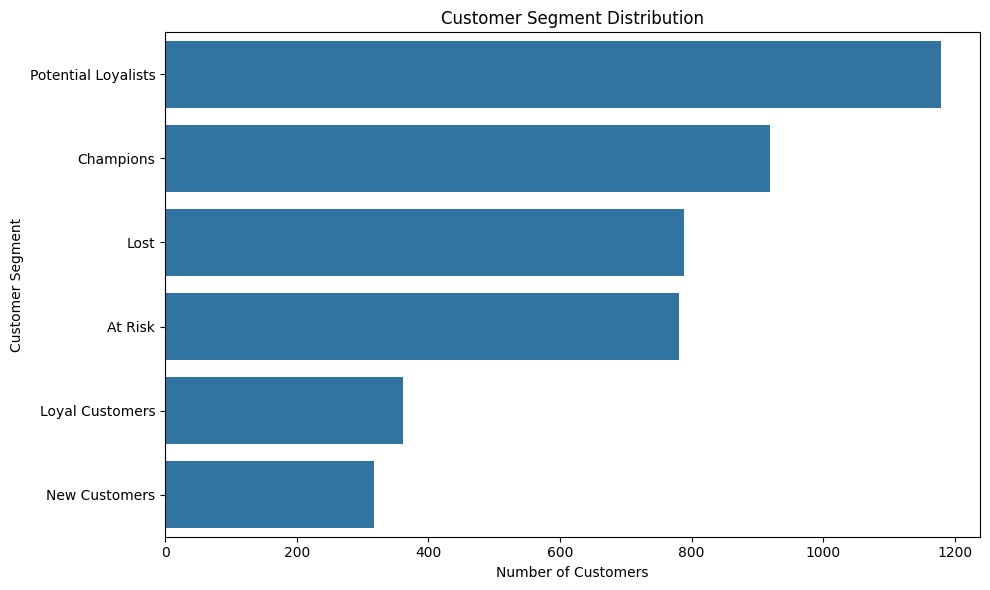

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_summary,
    x="Customer_Count",
    y="Segment"
)

plt.title("Customer Segment Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
plt.tight_layout()

plt.savefig("segment_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


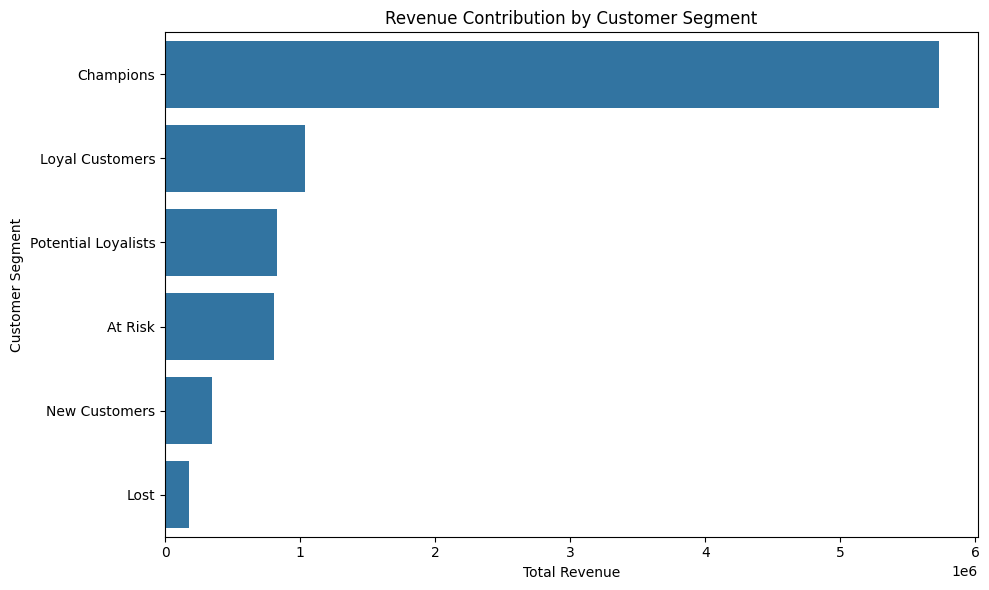

In [19]:
revenue_by_segment = (
    customer_rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

revenue_by_segment.columns = ["Segment", "Total_Revenue"]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=revenue_by_segment,
    x="Total_Revenue",
    y="Segment"
)

plt.title("Revenue Contribution by Customer Segment")
plt.xlabel("Total Revenue")
plt.ylabel("Customer Segment")
plt.tight_layout()

plt.savefig("revenue_by_segment.png", dpi=300, bbox_inches="tight")
plt.show()

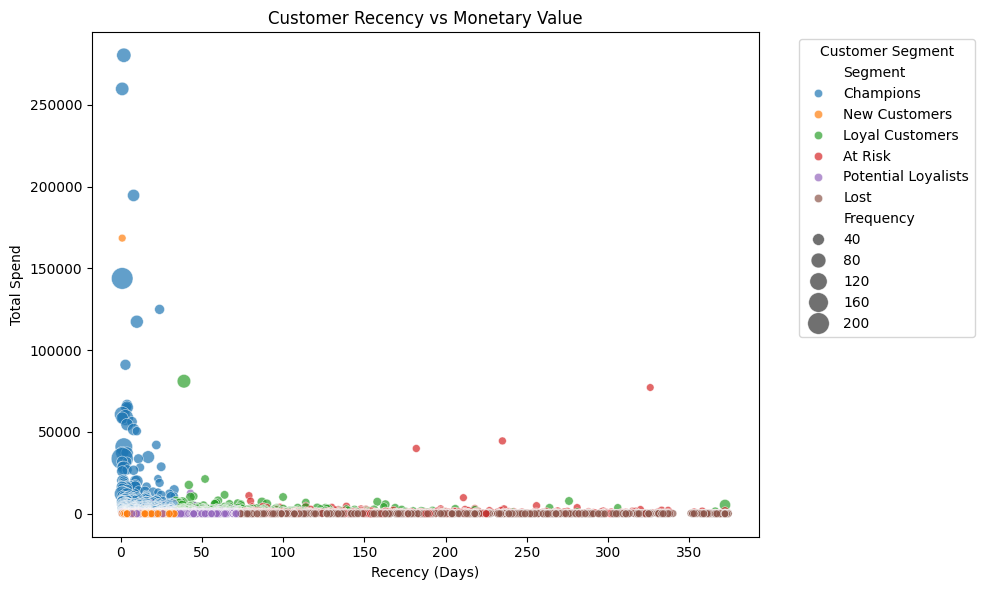

In [20]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customer_rfm,
    x="Recency",
    y="Monetary",
    hue="Segment",
    size="Frequency",
    sizes=(30, 250),
    alpha=0.7
)

plt.title("Customer Recency vs Monetary Value")
plt.xlabel("Recency (Days)")
plt.ylabel("Total Spend")
plt.legend(
    title="Customer Segment",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig("rfm_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
segment_analysis = (
    customer_rfm
    .groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum")
    )
    .reset_index()
)

segment_analysis["Revenue_Share_%"] = (
    segment_analysis["Total_Revenue"]
    / segment_analysis["Total_Revenue"].sum()
    * 100
)

segment_analysis = segment_analysis.sort_values(
    "Total_Revenue",
    ascending=False
)

segment_analysis.round(2)

,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_Share_%
1,Champions,919,12.51,11.46,6237.14,5731932.08,64.15
3,Loyal Customers,362,78.54,6.41,2870.38,1039078.07,11.63
5,Potential Loyalists,1179,36.33,2.38,704.94,831119.10,9.30
0,At Risk,780,168.38,2.22,1037.20,809019.68,9.05
4,New Customers,317,18.48,1.24,1091.70,346069.17,3.87
2,Lost,789,230.50,1.00,226.27,178528.57,2.00


In [22]:
display(
    segment_analysis[
        [
            "Segment",
            "Customers",
            "Avg_Recency",
            "Avg_Frequency",
            "Avg_Monetary",
            "Total_Revenue",
            "Revenue_Share_%"
        ]
    ].round(2)
)

,Segment,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_Share_%
1,Champions,919,12.51,11.46,6237.14,5731932.08,64.15
3,Loyal Customers,362,78.54,6.41,2870.38,1039078.07,11.63
5,Potential Loyalists,1179,36.33,2.38,704.94,831119.10,9.30
0,At Risk,780,168.38,2.22,1037.20,809019.68,9.05
4,New Customers,317,18.48,1.24,1091.70,346069.17,3.87
2,Lost,789,230.50,1.00,226.27,178528.57,2.00


In [23]:
# Calculate key business insights

total_customers = customer_rfm["CustomerID"].nunique()
total_revenue = customer_rfm["Monetary"].sum()

champions = segment_analysis[
    segment_analysis["Segment"] == "Champions"
].iloc[0]

at_risk = segment_analysis[
    segment_analysis["Segment"] == "At Risk"
].iloc[0]

lost = segment_analysis[
    segment_analysis["Segment"] == "Lost"
].iloc[0]

potential = segment_analysis[
    segment_analysis["Segment"] == "Potential Loyalists"
].iloc[0]

new_customers = segment_analysis[
    segment_analysis["Segment"] == "New Customers"
].iloc[0]

print(f"Total customers analyzed: {total_customers:,}")
print(f"Total revenue analyzed: £{total_revenue:,.2f}")
print()

print(
    f"1. Champions: {champions['Customers']:,} customers "
    f"generate {champions['Revenue_Share_%']:.1f}% of total revenue."
)

print(
    f"2. At Risk: {at_risk['Customers']:,} customers "
    f"have an average recency of {at_risk['Avg_Recency']:.0f} days "
    f"and contribute {at_risk['Revenue_Share_%']:.1f}% of revenue."
)

print(
    f"3. Lost: {lost['Customers']:,} customers "
    f"have an average recency of {lost['Avg_Recency']:.0f} days."
)

print(
    f"4. Potential Loyalists: {potential['Customers']:,} customers "
    f"represent {potential['Revenue_Share_%']:.1f}% of revenue."
)

print(
    f"5. New Customers: {new_customers['Customers']:,} customers "
    f"have an average frequency of {new_customers['Avg_Frequency']:.2f} orders."
)

Total customers analyzed: 4,338
Total revenue analyzed: £8,935,746.67

1. Champions: 919 customers generate 64.1% of total revenue.
2. At Risk: 780 customers have an average recency of 168 days and contribute 9.1% of revenue.
3. Lost: 789 customers have an average recency of 231 days.
4. Potential Loyalists: 1,179 customers represent 9.3% of revenue.
5. New Customers: 317 customers have an average frequency of 1.24 orders.


In [24]:
rfm_segment_scores = (
    customer_rfm
    .groupby("Segment")
    .agg(
        Recency_Score=("R_Score", "mean"),
        Frequency_Score=("F_Score", "mean"),
        Monetary_Score=("M_Score", "mean")
    )
    .reset_index()
)

rfm_segment_scores

,Segment,Recency_Score,Frequency_Score,Monetary_Score
0,At Risk,1.606410,2.637179,2.923077
1,Champions,4.597388,4.725789,4.655060
2,Lost,1.315589,1.523447,1.397972
3,Loyal Customers,2.560773,4.461326,4.497238
4,New Customers,4.315457,1.583596,2.160883
5,Potential Loyalists,3.643766,2.813401,2.597116


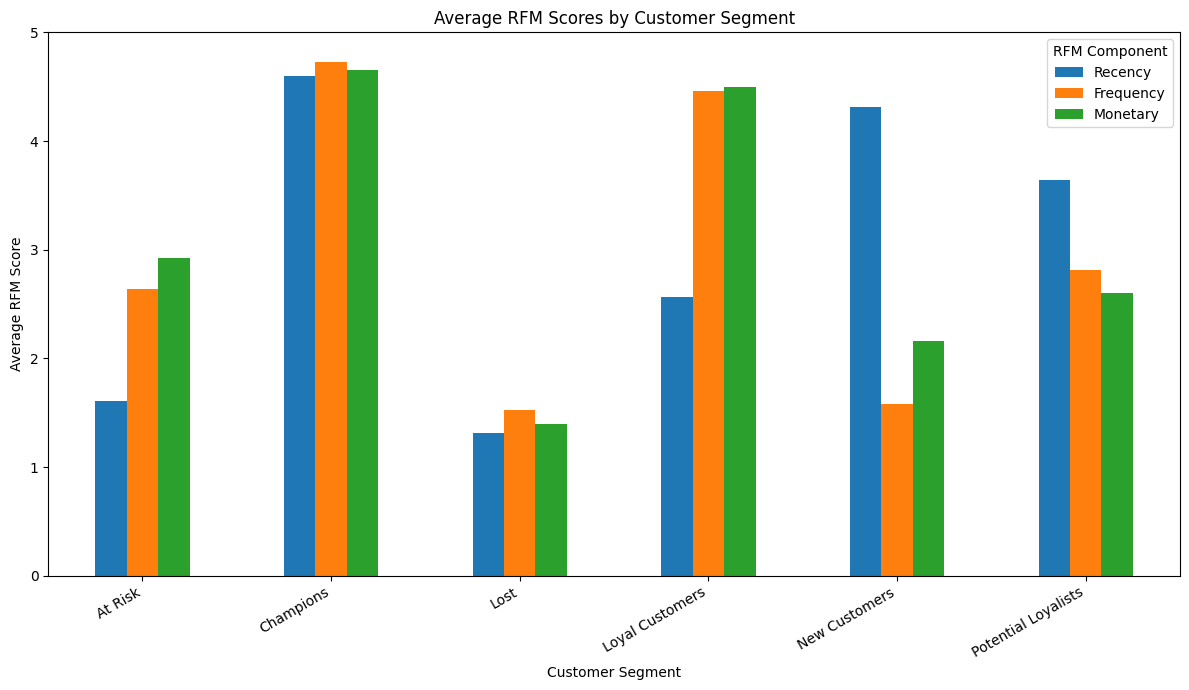

In [25]:
rfm_plot = rfm_segment_scores.set_index("Segment")

rfm_plot.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Average RFM Scores by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average RFM Score")
plt.xticks(rotation=30, ha="right")
plt.legend(
    title="RFM Component",
    labels=["Recency", "Frequency", "Monetary"]
)
plt.ylim(0, 5)
plt.tight_layout()

plt.savefig("rfm_segment_comparison.png", dpi=300, bbox_inches="tight")
plt.show()